  Activating project at `~/lib/git/GPEC`
┌ Info: Forcing hamada coordinate jacobian exponents: power_*
└ @ GeneralizedPerturbedEquilibrium.Equilibrium /home/jmlmir/lib/git/GPEC/src/Equilibrium/EquilibriumTypes.jl:68
┌ Info: Processing EFIT g-file: /home/jmlmir/lib/git/GPEC/examples/DIIID-like_ideal_example/TkMkr_D3Dlike_Hmode.geqdsk
└ @ GeneralizedPerturbedEquilibrium.Equilibrium /home/jmlmir/lib/git/GPEC/src/Equilibrium/ReadEquilibrium.jl:58
┌ Info: Parsed from header: nw=257, nh=257
└ @ GeneralizedPerturbedEquilibrium.Equilibrium /home/jmlmir/lib/git/GPEC/src/Equilibrium/ReadEquilibrium.jl:65
┌ Info: Magnetic axis found at R = 1.744, Z = -0.005
└ @ GeneralizedPerturbedEquilibrium.Equilibrium /home/jmlmir/lib/git/GPEC/src/Equilibrium/DirectEquilibrium.jl:179
┌ Info: Inboard separatrix found at R = 1.058
└ @ GeneralizedPerturbedEquilibrium.Equilibrium /home/jmlmir/lib/git/GPEC/src/Equilibrium/DirectEquilibrium.jl:208
┌ Info: Outboard separatrix found at R = 2.301
└ @ GeneralizedPerturb


s extrema
  index	psi_norm	value
  155	0.91006135	3.098059626449e+00
  163	0.95668712	2.218338914722e+00

alpha extrema
  index	psi_norm	value
  75	0.44380368	1.475989118427e+01
  109	0.64196319	1.449804644503e+01
  164	0.96251534	2.090707893518e+02


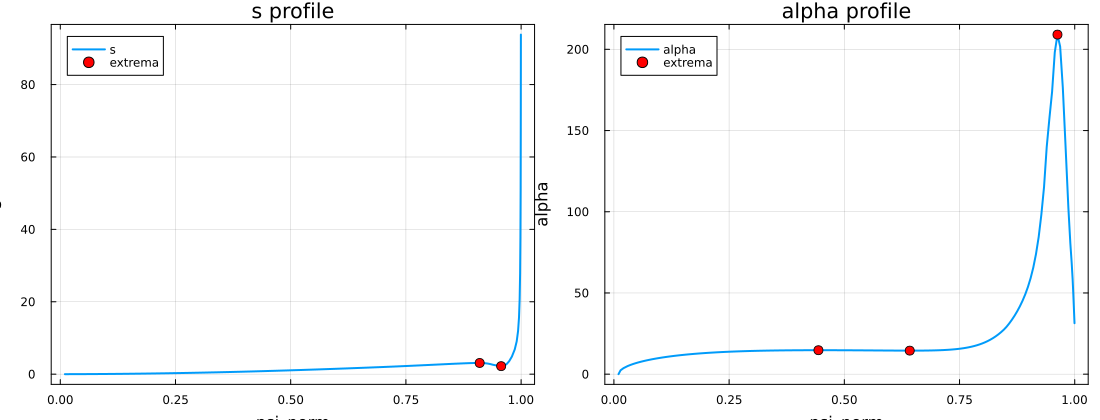

In [1]:
using Pkg
Pkg.activate("../..")

using GeneralizedPerturbedEquilibrium
using Plots
using Printf
using Statistics
using LaTeXStrings
using TOML

eq_config = GeneralizedPerturbedEquilibrium.Equilibrium.EquilibriumConfig(TOML.parsefile("gpec.toml")["Equilibrium"], pwd())
equil = GeneralizedPerturbedEquilibrium.Equilibrium.setup_equilibrium(eq_config)
psi_norm = Vector(equil.profiles.xs)

function finite_local_extrema(values::AbstractVector{<:Real})
    extrema = Int[]
    for i in 2:length(values)-1
        if !isfinite(values[i - 1]) || !isfinite(values[i]) || !isfinite(values[i + 1])
            continue
        end
        if (values[i] >= values[i - 1] && values[i] >= values[i + 1]) ||
           (values[i] <= values[i - 1] && values[i] <= values[i + 1])
            push!(extrema, i)
        end
    end
    return extrema
end

function print_extrema_report(name::String, psi::AbstractVector, values::AbstractVector, extrema::AbstractVector{Int})
    println("\n", name, " extrema")
    if isempty(extrema)
        println("  none")
        return
    end
    println("  index\tpsi_norm\tvalue")
    for i in extrema
        @printf("  %d\t%.8f\t%.12e\n", i, psi[i], values[i])
    end
end

s_profile = fill(NaN, length(psi_norm))
alpha_profile = fill(NaN, length(psi_norm))

for i in eachindex(psi_norm)
    try
        ref = GeneralizedPerturbedEquilibrium.ForceFreeStates.salpha_reference(i, equil)
        s_profile[i] = ref.s_ref
        alpha_profile[i] = ref.alpha_ref
    catch err
        @warn "s-alpha reference failed" i psi=psi_norm[i] exception=(err, catch_backtrace())
    end
end

s_extrema = finite_local_extrema(s_profile)
alpha_extrema = finite_local_extrema(alpha_profile)
print_extrema_report("s", psi_norm, s_profile, s_extrema)
print_extrema_report("alpha", psi_norm, alpha_profile, alpha_extrema)

s_mask = isfinite.(s_profile)
alpha_mask = isfinite.(alpha_profile)

p_s = plot(
    psi_norm[s_mask], s_profile[s_mask];
    xlabel="psi_norm",
    ylabel="s",
    label="s",
    lw=2,
    title="s",
    framestyle=:box,
)
scatter!(p_s, psi_norm[s_extrema], s_profile[s_extrema]; label="extrema", marker=:circle, color=:red, ms=5)

p_alpha = plot(
    psi_norm[alpha_mask], alpha_profile[alpha_mask];
    xlabel="psi_norm",
    ylabel="alpha",
    label="alpha",
    lw=2,
    title="alpha",
    framestyle=:box,
)
scatter!(p_alpha, psi_norm[alpha_extrema], alpha_profile[alpha_extrema]; label="extrema", marker=:circle, color=:red, ms=5)

display(plot(p_s, p_alpha; layout=(1, 2), size=(1100, 420)))


Computing Delta' and Di profiles...


┌ Warning: Verbosity toggle: dt_min_unstable 
│  dt(1.0e-10 <= dtmin(1.0e-10), at t=-0.06510113282556569, and step error estimate = 1.1423556107565442. Aborting. There is either an error in your model specification or the true solution is unstable.
└ @ SciMLBase /home/jmlmir/.julia/packages/SciMLBase/hLfdZ/src/integrator_interface.jl:717
┌ Warning: Verbosity toggle: dt_min_unstable 
│  dt(1.0e-10 <= dtmin(1.0e-10), at t=-0.09646835664820956, and step error estimate = 1.0233429309893254. Aborting. There is either an error in your model specification or the true solution is unstable.
└ @ SciMLBase /home/jmlmir/.julia/packages/SciMLBase/hLfdZ/src/integrator_interface.jl:717



Delta' extrema
  index	psi_norm	value
  22	0.13490798	-2.270043132951e-02
  23	0.14073620	-2.273200742321e-02
  25	0.15239264	-2.262453359539e-02
  26	0.15822086	-2.268353986142e-02
  27	0.16404908	-2.265515889541e-02
  116	0.68276074	-3.370657448578e-02
  160	0.93920245	-8.756024762877e-03
  162	0.95085890	-1.227486100615e-02
  166	0.97417178	-6.900060910302e-03
  174	0.99848787	-2.375793842651e-02

Di extrema
  index	psi_norm	value
  125	0.73521472	-2.637864264262e-01
  163	0.95668712	-7.776704310230e-01
  175	0.99895436	-2.527139701487e-01
  176	0.99927694	-2.528430789462e-01


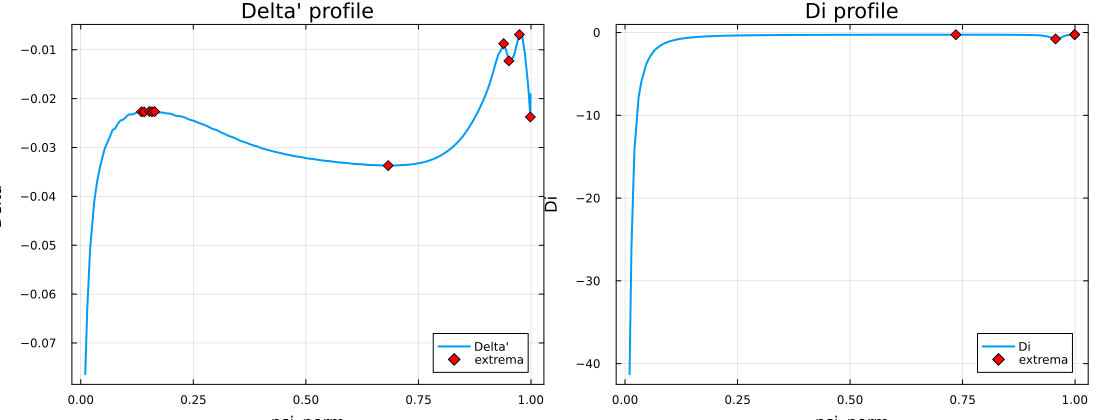

In [2]:
locstab_fs = zeros(length(psi_norm), 4)
ctrl = GeneralizedPerturbedEquilibrium.ForceFreeStates.ForceFreeStatesControl(verbose=false)

println("Computing \\Delta' and D_I...")
GeneralizedPerturbedEquilibrium.ForceFreeStates.compute_ballooning_stability!(ctrl, locstab_fs, equil; compute_delta_prime=true)

delta_prime = Vector(locstab_fs[:, 4])
di_profile = fill(NaN, length(psi_norm))
psi_mask = abs.(psi_norm) .> eps(Float64)
di_profile[psi_mask] .= locstab_fs[psi_mask, 1] ./ psi_norm[psi_mask]

delta_extrema = finite_local_extrema(delta_prime)
di_extrema = finite_local_extrema(di_profile)
print_extrema_report("\\Delta'", psi_norm, delta_prime, delta_extrema)
print_extrema_report("D_I", psi_norm, di_profile, di_extrema)

delta_mask = isfinite.(delta_prime)
di_mask = isfinite.(di_profile)

p_delta = plot(
    psi_norm[delta_mask], delta_prime[delta_mask];
    xlabel="psi_norm",
    ylabel=L"\Delta'",
    label=L"\Delta'",
    lw=2,
    title=L"\Delta'",
    framestyle=:box,
)
scatter!(p_delta, psi_norm[delta_extrema], delta_prime[delta_extrema]; label="extrema", marker=:diamond, color=:red, ms=5)

p_di = plot(
    psi_norm[di_mask], di_profile[di_mask];
    xlabel="psi_norm",
    ylabel=L"D_I",
    label=L"D_I",
    lw=2,
    title=L"D_I",
    framestyle=:box,
)
scatter!(p_di, psi_norm[di_extrema], di_profile[di_extrema]; label="extrema", marker=:diamond, color=:red, ms=5)

display(plot(p_delta, p_di; layout=(1, 2), size=(1100, 420)))


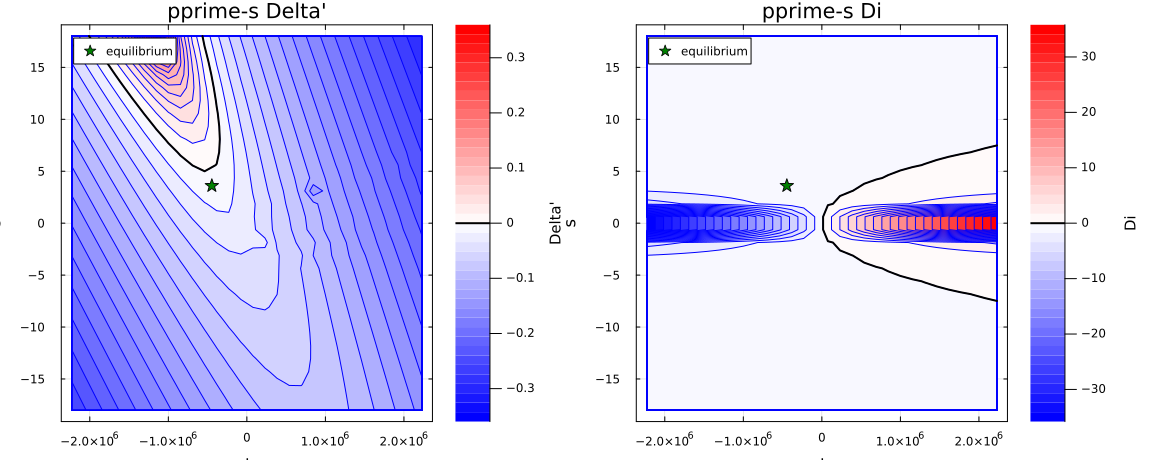

Running s-alpha scan at index 166, psi_norm=0.974172


In [5]:
psi_target = 0.974
psi_idx_scan = argmin(abs.(psi_norm .- psi_target))

println("Running s-alpha scan at index $(psi_idx_scan), psi_norm=$(round(psi_norm[psi_idx_scan], digits=6))")

s_scales = collect(range(-5.0, 5.0; length=30))
alpha_scales = collect(range(-5.0, 5.0; length=30))

scan_result = GeneralizedPerturbedEquilibrium.ForceFreeStates.scan_delta_prime_map(
    psi_idx_scan,
    equil;
    theta_k=0.0,
    s_scales=s_scales,
    alpha_scales=alpha_scales,
)

scan_qprime_raw = scan_result.dqdpsi_ref .* scan_result.s_scales
scan_pprime_raw = scan_result.pprime_ref .* scan_result.alpha_scales
qprime_order = sortperm(scan_qprime_raw)
pprime_order = sortperm(scan_pprime_raw)
scan_qprime = scan_qprime_raw[qprime_order]
scan_pprime = scan_pprime_raw[pprime_order]
scan_delta = scan_result.delta_prime[qprime_order, pprime_order]
scan_di = scan_result.di_values[qprime_order, pprime_order]

function symmetric_clims(z)
    finite_vals = vec(z)[isfinite.(vec(z))]
    maxabs = isempty(finite_vals) ? 1.0 : maximum(abs.(finite_vals))
    maxabs = max(maxabs, eps(Float64))
    return (-maxabs, maxabs)
end

p_scan_delta = contourf(
    scan_pprime, scan_qprime, scan_delta;
    c=cgrad([:blue, :white, :red]),
    clims=symmetric_clims(scan_delta),
    xlabel=L"p_{\psi}",
    ylabel=L"q_{\psi}",
    title=L"\Delta'",
    levels=41,
    framestyle=:box,
)
contour!(p_scan_delta, scan_pprime, scan_qprime, scan_delta; levels=[0.0], color=:black, linewidth=2, label=L"\Delta' = 0")
scatter!(p_scan_delta, [scan_result.reference.pprime_ref], [scan_result.reference.qprime_ref]; color=:green, marker=:star5, ms=7, label="equilibrium")

p_scan_di = contourf(
    scan_pprime, scan_qprime, scan_di;
    c=cgrad([:blue, :white, :red]),
    clims=symmetric_clims(scan_di),
    xlabel=L"p_{\psi}",
    ylabel=L"q_{\psi}",
    title=L"D_I",
    levels=41,
    framestyle=:box,
)
contour!(p_scan_di, scan_pprime, scan_qprime, scan_di; levels=[0.0], color=:black, linewidth=2, label=L"D_I = 0")
scatter!(p_scan_di, [scan_result.reference.pprime_ref], [scan_result.reference.qprime_ref]; color=:green, marker=:star5, ms=7, label="equilibrium")

display(plot(p_scan_delta, p_scan_di; layout=(1, 2), size=(1150, 460)))


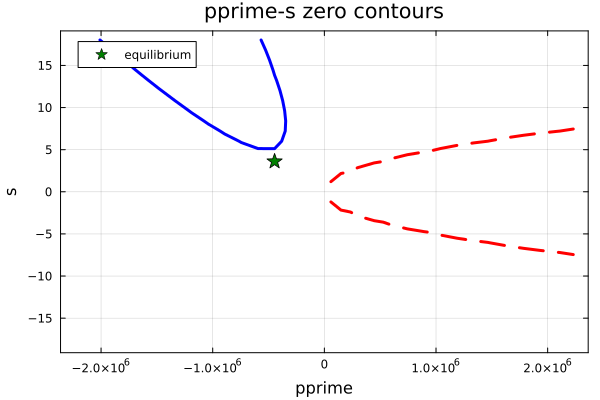

In [ ]:
p_zero = plot(
    xlabel=L"p_{\psi}",
    ylabel=L"q_{\psi}",
    title="ballooning, Mercier contours",
    framestyle=:box,
)
contour!(p_zero, scan_pprime, scan_qprime, scan_delta;
    levels=[0.0], color=:blue, linewidth=3,
    label=L"\Delta' = 0", colorbar=false)

contour!(p_zero, scan_pprime, scan_qprime, scan_di;
    levels=[0.0], color=:red, linewidth=3, linestyle=:dash,
    label=L"D_I = 0", colorbar=false)


scatter!(p_zero, [scan_result.reference.pprime_ref], [scan_result.reference.qprime_ref]; color=:green, marker=:star5, ms=8, label="equilibrium")
display(p_zero)
